<a href="https://colab.research.google.com/github/EduRubira2/Rubira_lib/blob/main/PontoFixo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nome: <font color="red">**Eduardo Nunes Rubira**</font>\
Matrícula:<font color="red"> **169555**</font>\
Método: <font color="red">**Ponto Fixo**</font>


Resumo: ***O Método do Ponto Fixo garante a rapidez dos resultados entretanto pode divergir por ser um método aberto, caso queira garantir a convergencia use o método da Bissecção, ela EXIGE que o x seja isolado de um lado da equação, ou seja, definindo um ponto fixo, sendo uma função x = g(x)***

***Ele não tende a encontrar um ponto no eixo x por conta que ele irá buscar convergir para a função x, por conta de sua isolação, é o encontro da reta Y(x) com G(x)***


***Quando o metodo do ponto fixo irá convergir: será quando a condição de Lipschitz for valida, e principalmente quando a inclinação da derivada for menor que 1***

***
| Caso | Condição | Sinal de $g'(x)$ | $|g'(x)|$ | Comportamento |
| :---: | :---: | :---: | :---: | :--- |
| (a) | $0 < g'(x) < 1$ | $> 0$ | $< 1$ | Convergência monotônica |
| (b) | $-1 < g'(x) < 0$ | $< 0$ | $< 1$ | Convergência oscilatória |
| (c) | $g'(x) > 1$ | $> 0$ | $> 1$ | Divergência monotônica |
| (d) | $g'(x) < -1$ | $< 0$ | $> 1$ | Divergência oscilatória |***

  MÉTODO DO PONTO FIXO — Encontrar raiz de f(x) = 0

Digite f(x)  (ex: math.exp(-x) - x)       : x
Digite g(x)  (ex: math.exp(-x))             : math.exp(-x)
Valor inicial x₀                           : 0
Tolerância percentual (ex: 5 para 5%)      : 5
Número máximo de iterações                 : 10
Raiz verdadeira (Enter se não souber)      : 

  f(x) = x
  g(x) = math.exp(-x)
  x₀   = 0.0  |  Tolerância: 5.0%  |  Max iter: 10

Histórico de iterações:
------------------------------------------------------------
 iteração      x_n  x_(n+1)     εa (%)
        0 0.000000 1.000000 100.000000
        1 1.000000 0.367879 171.828183
        2 0.367879 0.692201  46.853639
        3 0.692201 0.500474  38.309147
        4 0.500474 0.606244  17.446790
        5 0.606244 0.545396  11.156623
        6 0.545396 0.579612   5.903351
        7 0.579612 0.560115   3.480867

  RESULTADOS
  [Obrigatório] Raiz encontrada : x1 ≈ 0.56011546
  [Obrigatório] Iterações       : 8
  [Opcional 1]  f(x1)           

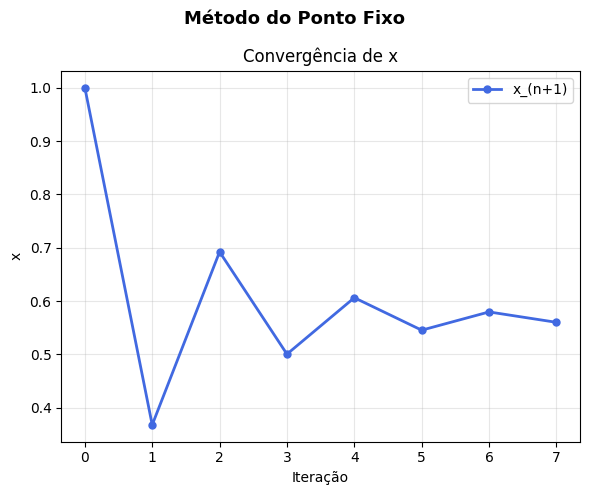

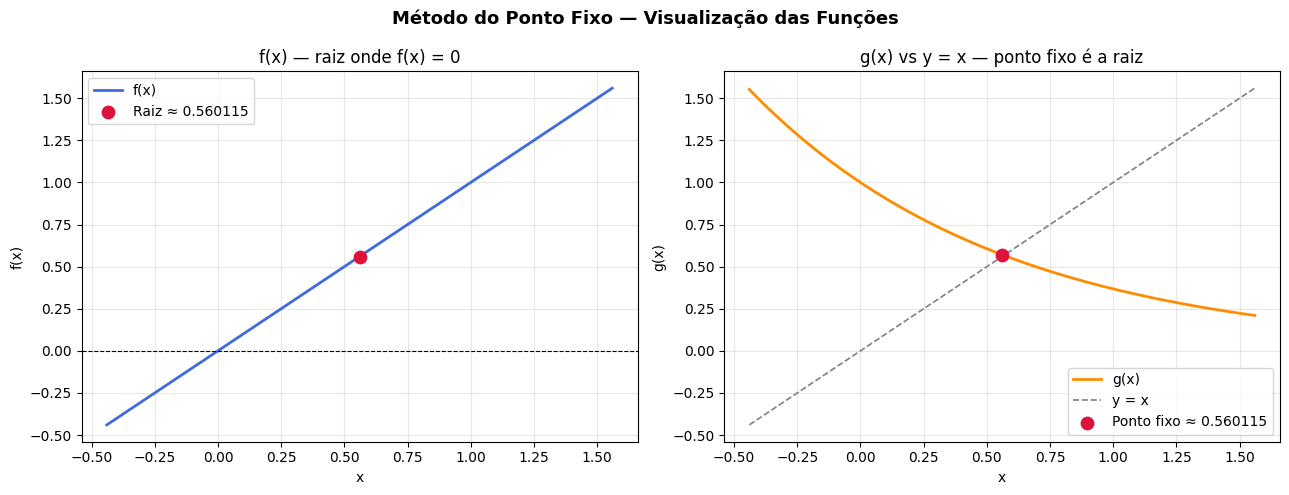

In [ ]:
"""
================================================================================
MÉTODO DO PONTO FIXO — Raízes de f(x) = 0
================================================================================
Disciplina : Métodos Numéricos
Autor      : Eduardo Nunes Rubira
Matrícula  : 169555
Data       : 2026-04-28
================================================================================

DESCRIÇÃO DO PROBLEMA:
    Dada uma equação f(x) = 0, reescreve-se como x = g(x) e itera-se:
        x_(n+1) = g(x_n)
    até que o erro relativo percentual seja menor que a tolerância.

    Exemplo clássico:
        f(x) = e^(-x) - x  →  g(x) = e^(-x)

MÉTODO UTILIZADO:
    Ponto Fixo — convergência garantida se |g'(x)| < 1 na vizinhança da raiz.

ENTRADAS:
    f_expr        → string com a expressão de f(x)
    g_expr        → string com a expressão de g(x) tal que x = g(x)
    x0            → chute inicial
    tol           → tolerância do erro relativo percentual (%)
    max_iter      → número máximo de iterações
    raiz_verdadeira → raiz analítica (opcional, para calcular erro real)

SAÍDAS:
    Obrigatórias:
        x1        → aproximação da raiz encontrada
        iterações → número de iterações realizadas
        aviso     → mensagem se não convergir

    Opcionais (todas implementadas):
        1. f(x1)  → valor da função na raiz aproximada
        2. Tabela → x1 e erro ao longo das iterações
        3. Gráfico do erro relativo por iteração
        4. Gráfico de f(x) e g(x) destacando a raiz aproximada
================================================================================
"""

# ==============================================================================
# 1. IMPORTS
# ==============================================================================
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


# ==============================================================================
# 2. FUNÇÕES AUXILIARES
# ==============================================================================

def criar_funcao(expr):
    """
    Compila uma string digitada pelo usuário em uma função Python segura.

    Parâmetros
    ----------
    expr : str
        Expressão matemática em função de x.
        Pode usar: math.exp, math.sin, math.cos, math.log, np.*, etc.
        Exemplo: "math.exp(-x) - x"

    Retorna
    -------
    callable
        Função f(x) avaliável numericamente.
    """
    def func(x):
        try:
            return eval(expr, {"x": x, "math": math, "np": np})
        except Exception:
            return float("nan")
    return func


# ==============================================================================
# 3. IMPLEMENTAÇÃO DO MÉTODO
# ==============================================================================

def ponto_fixo(g, x0, tol, max_iter, raiz_verdadeira=None):
    """
    Método do Ponto Fixo: itera x_(n+1) = g(x_n) até convergir.

    Parâmetros
    ----------
    g               : callable → função de iteração g(x)
    x0              : float    → chute inicial
    tol             : float    → tolerância do erro relativo percentual (%)
    max_iter        : int      → número máximo de iterações
    raiz_verdadeira : float | None → raiz analítica para cálculo do erro real

    Retorna
    -------
    x1      : float      → última aproximação calculada
    tabela  : list[dict] → histórico completo das iterações

    Levanta
    -------
    RuntimeWarning (via print)
        Se o método divergir ou atingir o máximo de iterações.
    """

    tabela = []

    for i in range(max_iter):

        x1 = g(x0)

        # --- Erro relativo aproximado ---
        erro_aprox = abs((x1 - x0) / x1) * 100 if x1 != 0 else float("inf")

        # --- Erro real (só se a raiz verdadeira for fornecida) ---
        erro_real = (
            abs((raiz_verdadeira - x1) / raiz_verdadeira) * 100
            if raiz_verdadeira is not None
            else float("nan")
        )

        tabela.append({
            "iteração":  i,
            "x_n":       x0,
            "x_(n+1)":   x1,
            "εa (%)":    erro_aprox,
            "erro real (%)": erro_real,
        })

        # --- Critério de parada ---
        if erro_aprox < tol:
            break

        x0 = x1

    else:
        print("Aviso: número máximo de iterações atingido sem convergência.")

    return x1, tabela


# ==============================================================================
# 4. SAÍDA / RELATÓRIO
# ==============================================================================

def imprimir_tabela(tabela, raiz_verdadeira):
    """
    Exibe o histórico de iterações formatado.

    Parâmetros
    ----------
    tabela          : list[dict]
    raiz_verdadeira : float | None
    """
    df = pd.DataFrame(tabela)

    # Remove coluna de erro real se não foi fornecida raiz verdadeira
    if raiz_verdadeira is None:
        df = df.drop(columns=["erro real (%)"])

    pd.set_option("display.float_format", "{:.6f}".format)
    print(df.to_string(index=False))
    return df


# ==============================================================================
# 5. VISUALIZAÇÃO
# ==============================================================================

def plotar_resultados(tabela, raiz_verdadeira, tol):
    """
    Gera dois gráficos:
      - Convergência de x_(n+1) ao longo das iterações
      - Erro relativo percentual por iteração

    Parâmetros
    ----------
    tabela          : list[dict] → histórico de iterações
    raiz_verdadeira : float | None
    tol             : float → tolerância usada (para linha de referência)
    """
    iteracoes  = [r["iteração"]   for r in tabela]
    valores_x  = [r["x_(n+1)"]   for r in tabela]
    erros_aprox = [r["εa (%)"]   for r in tabela]
    erros_reais = [r["erro real (%)"] for r in tabela]

    n_graficos = 2 if raiz_verdadeira is not None else 1
    fig, axs = plt.subplots(1, n_graficos, figsize=(6 * n_graficos, 5))
    fig.suptitle("Método do Ponto Fixo", fontsize=13, fontweight="bold")

    if n_graficos == 1:
        axs = [axs]

    # --- Gráfico 1: Convergência de x ---
    axs[0].plot(iteracoes, valores_x, marker="o", color="royalblue",
                linewidth=2, markersize=5, label="x_(n+1)")
    if raiz_verdadeira is not None:
        axs[0].axhline(raiz_verdadeira, color="crimson", linestyle="--",
                       linewidth=1.2, label=f"Raiz verdadeira = {raiz_verdadeira}")
    axs[0].set_title("Convergência de x")
    axs[0].set_xlabel("Iteração")
    axs[0].set_ylabel("x")
    axs[0].legend()
    axs[0].grid(True, alpha=0.3)

    # --- Gráfico 2: Erro real (só se raiz verdadeira foi informada) ---
    if raiz_verdadeira is not None:
        axs[1].plot(iteracoes, erros_reais, marker="x", color="darkorange",
                    linewidth=2, markersize=6, label="Erro real (%)")
        axs[1].axhline(tol, color="gray", linestyle="--",
                       linewidth=1, label=f"Tolerância = {tol}%")
        axs[1].set_title("Erro Real por Iteração")
        axs[1].set_xlabel("Iteração")
        axs[1].set_ylabel("Erro real (%)")
        axs[1].legend()
        axs[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("ponto_fixo_resultado.png", dpi=150)
    plt.show()


def plotar_funcoes(f, g, raiz, x0_original):
    """
    [Saída opcional 4] Gráfico de f(x) e g(x) no mesmo eixo,
    com a diagonal y = x e a raiz aproximada destacada.

    A interseção de g(x) com y = x é exatamente a raiz de f(x) = 0,
    o que ilustra geometricamente o método do ponto fixo.

    Parâmetros
    ----------
    f           : callable → função original f(x)
    g           : callable → função de iteração g(x)
    raiz        : float    → raiz aproximada encontrada
    x0_original : float    → chute inicial (para dimensionar o eixo x)
    """

    # Definir janela de visualização em torno da raiz
    margem = max(abs(raiz - x0_original) * 1.5, 1.0)
    x_min  = raiz - margem
    x_max  = raiz + margem
    x_vals = np.linspace(x_min, x_max, 400)

    # Avaliar f e g com segurança (nan onde não definida)
    f_vals = np.array([f(x) for x in x_vals], dtype=float)
    g_vals = np.array([g(x) for x in x_vals], dtype=float)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Método do Ponto Fixo — Visualização das Funções",
                 fontsize=13, fontweight="bold")

    # --- Painel esquerdo: f(x) com raiz marcada ---
    ax1.plot(x_vals, f_vals, color="royalblue", linewidth=2, label="f(x)")
    ax1.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax1.scatter([raiz], [f(raiz)], color="crimson", zorder=5, s=80,
                label=f"Raiz ≈ {raiz:.6f}")
    ax1.set_title("f(x) — raiz onde f(x) = 0")
    ax1.set_xlabel("x")
    ax1.set_ylabel("f(x)")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # --- Painel direito: g(x) e diagonal y = x ---
    # A raiz de f é o ponto fixo de g, onde g(x) = x
    ax2.plot(x_vals, g_vals, color="darkorange", linewidth=2, label="g(x)")
    ax2.plot(x_vals, x_vals, color="gray",       linewidth=1.2,
             linestyle="--", label="y = x")
    ax2.scatter([raiz], [g(raiz)], color="crimson", zorder=5, s=80,
                label=f"Ponto fixo ≈ {raiz:.6f}")
    ax2.set_title("g(x) vs y = x — ponto fixo é a raiz")
    ax2.set_xlabel("x")
    ax2.set_ylabel("g(x)")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("ponto_fixo_funcoes.png", dpi=150)
    plt.show()


# ==============================================================================
# 6. PROGRAMA PRINCIPAL
# ==============================================================================

def main():
    print("=" * 60)
    print("  MÉTODO DO PONTO FIXO — Encontrar raiz de f(x) = 0")
    print("=" * 60)

    # --- Entradas do usuário ---
    try:
        f_expr = input("\nDigite f(x)  (ex: math.exp(-x) - x)       : ")
        g_expr = input("Digite g(x)  (ex: math.exp(-x))             : ")
        x0     = float(input("Valor inicial x₀                           : "))
        tol    = float(input("Tolerância percentual (ex: 5 para 5%)      : "))
        max_iter = int(input("Número máximo de iterações                 : "))

        raiz_input      = input("Raiz verdadeira (Enter se não souber)      : ")
        raiz_verdadeira = float(raiz_input) if raiz_input.strip() else None

    except ValueError as e:
        print(f"\nErro na entrada de dados: {e}")
        return

    print("\n" + "=" * 60)
    print(f"  f(x) = {f_expr}")
    print(f"  g(x) = {g_expr}")
    print(f"  x₀   = {x0}  |  Tolerância: {tol}%  |  Max iter: {max_iter}")
    print("=" * 60)

    # --- Montar função g ---
    g = criar_funcao(g_expr)

    # --- Executar o método ---
    try:
        raiz, tabela = ponto_fixo(g, x0, tol, max_iter, raiz_verdadeira)
    except Exception as e:
        print(f"\nErro durante a execução do método: {e}")
        return

    # --- Imprimir tabela ---
    print("\nHistórico de iterações:")
    print("-" * 60)
    imprimir_tabela(tabela, raiz_verdadeira)

    # --- Resultados finais (saídas obrigatórias + opcional 1) ---
    f = criar_funcao(f_expr)
    print("\n" + "=" * 60)
    print("  RESULTADOS")
    print("=" * 60)
    print(f"  [Obrigatório] Raiz encontrada : x1 ≈ {raiz:.8f}")
    print(f"  [Obrigatório] Iterações       : {len(tabela)}")
    print(f"  [Opcional 1]  f(x1)           : {f(raiz):.2e}  (deve ser ≈ 0)")
    print("=" * 60)

    # --- Gráfico erro por iteração (opcional 3) + convergência ---
    plotar_resultados(tabela, raiz_verdadeira, tol)

    # --- Gráfico de f(x) e g(x) (opcional 4) ---
    plotar_funcoes(f, g, raiz, x0)


# ==============================================================================
# Ponto de entrada padrão Python
# ==============================================================================
if __name__ == "__main__":
    main()